In [9]:
import pandas as pd
from ydata_profiling import ProfileReport
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
from sklearn.model_selection import cross_val_score
%matplotlib inline


In [10]:
df = pd.read_csv('E:/Downloads/Mall_Customers.csv')

In [11]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])


In [14]:
#df = df.drop(['CustomerID'],axis=1)

In [15]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [16]:
df.shape

(200, 5)

In [17]:
def remove_outliers_iqr(df, columns):
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((df[columns] < (Q1 - 1.5 * IQR)) | (df[columns] > (Q3 + 1.5 * IQR))).any(axis=1)
    return df[mask]
df_no_outliers = remove_outliers_iqr(df, df.select_dtypes(include=[np.number]).columns)
print('Original shape:', df.shape)
print('Shape after outlier removal:', df_no_outliers.shape)
df = df_no_outliers.reset_index(drop=True)

Original shape: (200, 5)
Shape after outlier removal: (198, 5)


In [18]:
ftrs = df[['Gender','Age','Annual Income (k$)','Spending Score (1-100)']]



In [19]:
ftrs.shape

(198, 4)

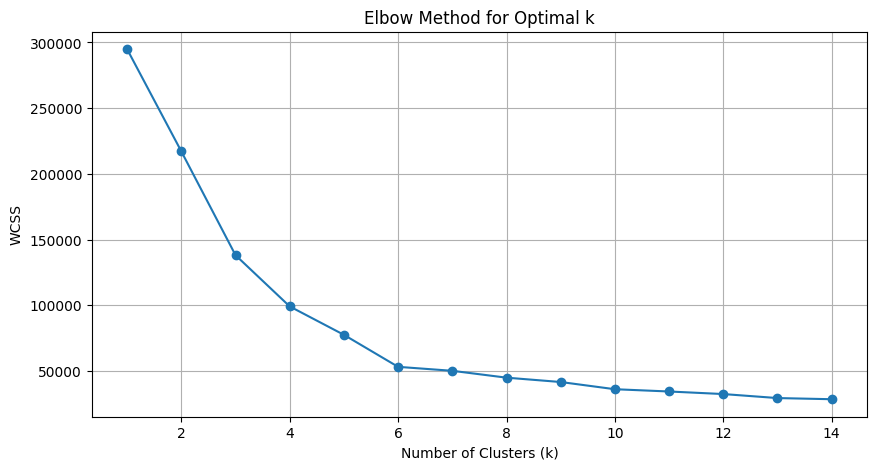

In [20]:
wcss = [] #within cluster sum of squares used evaluate how well the data points are clustered around their respective centroids in K-Means.


for k in range (1,15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


[0.31439875001299095, 0.3793577446939934, 0.40758212907644736, 0.3824283413283823, 0.45955989969588884, 0.408525470462943, 0.43197205554915685, 0.4192240627366814, 0.40338066847404896, 0.3913690173634895, 0.38862453353679466, 0.36709531446179056, 0.3576389723902705]


Text(0.5, 0, 'Number of Clusters (k)')

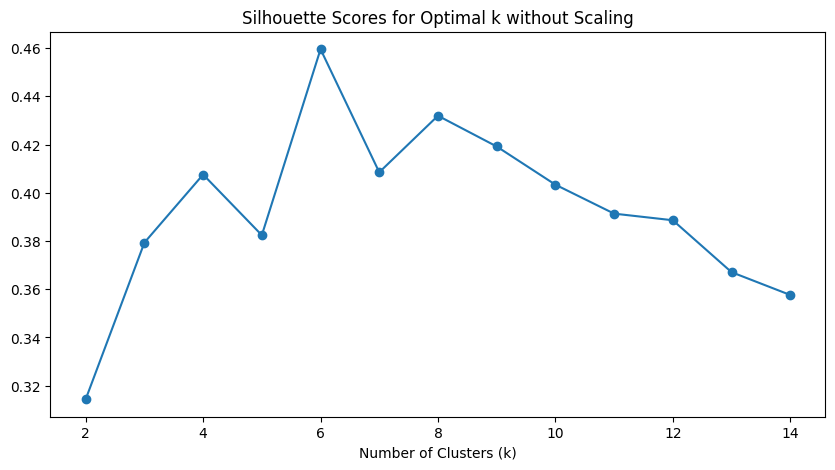

In [21]:
silhouette_scores = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs)
    score = silhouette_score(ftrs, kmeans.labels_)
    silhouette_scores.append(score)
print (silhouette_scores)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k without Scaling')
plt.xlabel('Number of Clusters (k)')

0.4275 highest silhoutte score at K=10 almost

In [22]:
scalar = StandardScaler()
ftrs_scaled = scalar.fit_transform(ftrs)

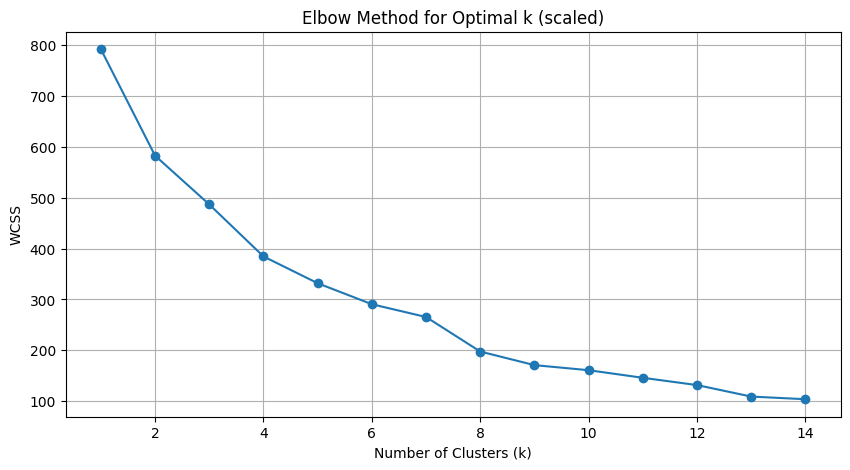

In [23]:
wcss = [] #within cluster sum of squares used evaluate how well the data points are clustered around their respective centroids in K-Means.


for k in range (1,15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method for Optimal k (scaled)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


[0.25090045818546425, 0.27177366124271, 0.2989514866332462, 0.30457285645416543, 0.3186844232443084, 0.3123224456356529, 0.3914697863773164, 0.4043582839406131, 0.38177771336302013, 0.399448258693048, 0.41278002020609, 0.4365793724587708, 0.413017299499747]


Text(0.5, 0, 'Number of Clusters (k)')

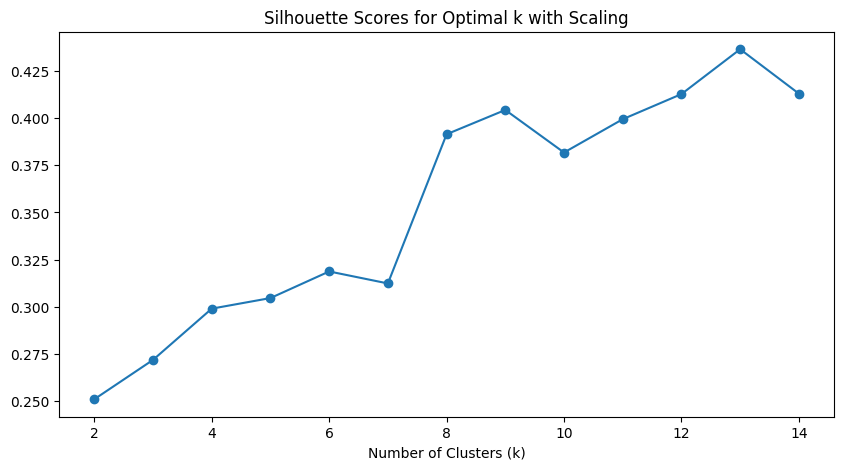

In [24]:
silhouette_scores = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs_scaled)
    score = silhouette_score(ftrs_scaled, kmeans.labels_)
    silhouette_scores.append(score)
print (silhouette_scores)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k with Scaling')
plt.xlabel('Number of Clusters (k)')

SAme with scaling

In [25]:
pca = PCA(n_components=2)
ftrs_pca = pca.fit_transform(ftrs_scaled)

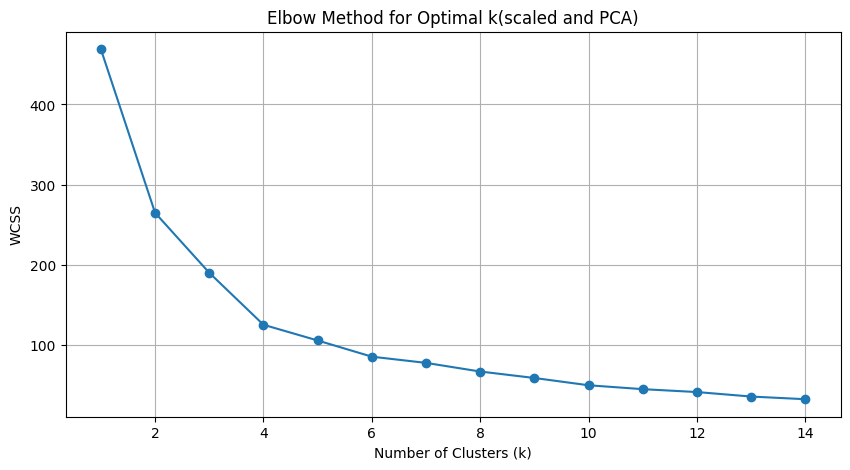

In [26]:
wcss = []
for k in range (1,15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs_pca)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method for Optimal k(scaled and PCA)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

[0.39952165801541323, 0.3867640398605271, 0.39686929198818405, 0.3777020529477278, 0.3935824698369047, 0.37708215924215127, 0.36286133935304205, 0.3558954145161025, 0.3785254568991236, 0.39316014459915083, 0.3867394541351721, 0.39757370659918606, 0.4028030650851611]


Text(0.5, 0, 'Number of Clusters (k)')

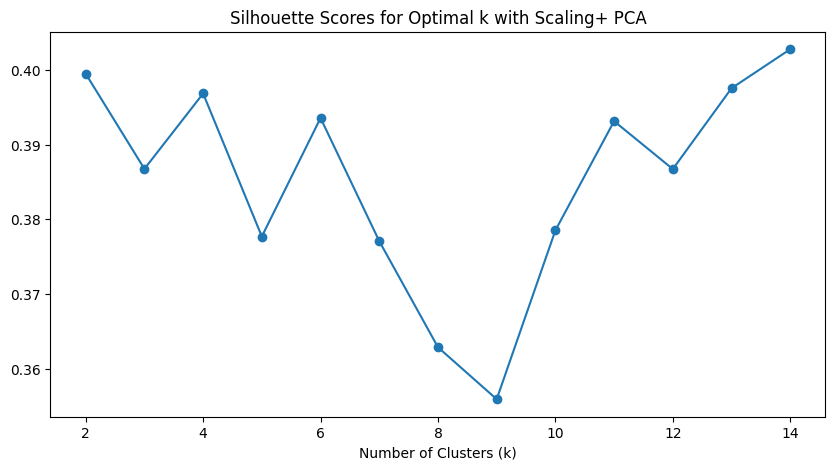

In [27]:
silhouette_scores = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs_pca)
    score = silhouette_score(ftrs_pca, kmeans.labels_)
    silhouette_scores.append(score)
print (silhouette_scores)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k with Scaling+ PCA')
plt.xlabel('Number of Clusters (k)')

PCA + Scaling silhoutte score = 0.4123
scaling only silhoutte score = 0.4275

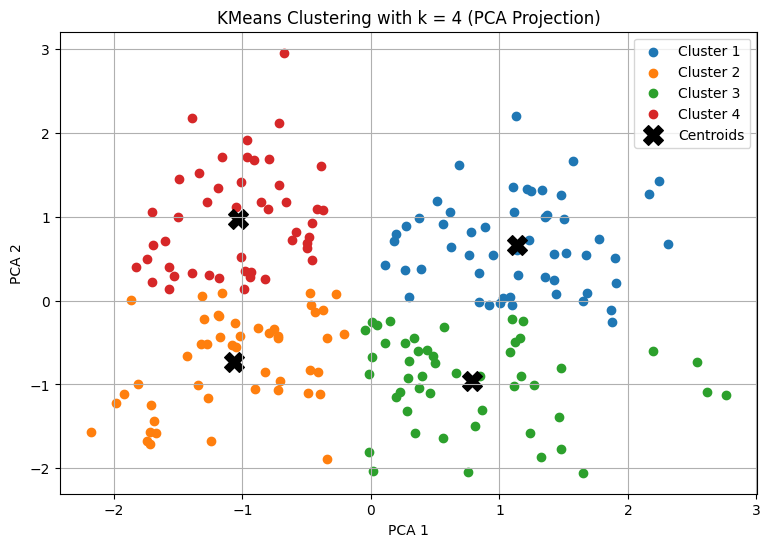

In [28]:
# KMeans clustering with k=4 and PCA projection for visualization
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(ftrs_pca)
plt.figure(figsize=(9,6))
for i in range(4):
    plt.scatter(ftrs_pca[clusters == i, 0], ftrs_pca[clusters == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('KMeans Clustering with k = 4 (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

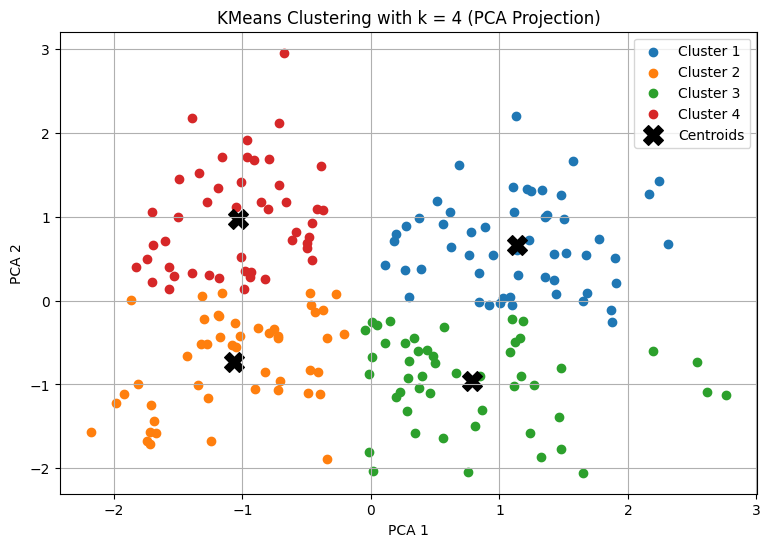

In [29]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(ftrs_pca)
plt.figure(figsize=(9,6))
for i in range(4):
    plt.scatter(ftrs_pca[clusters == i, 0], ftrs_pca[clusters == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('KMeans Clustering with k = 4 (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

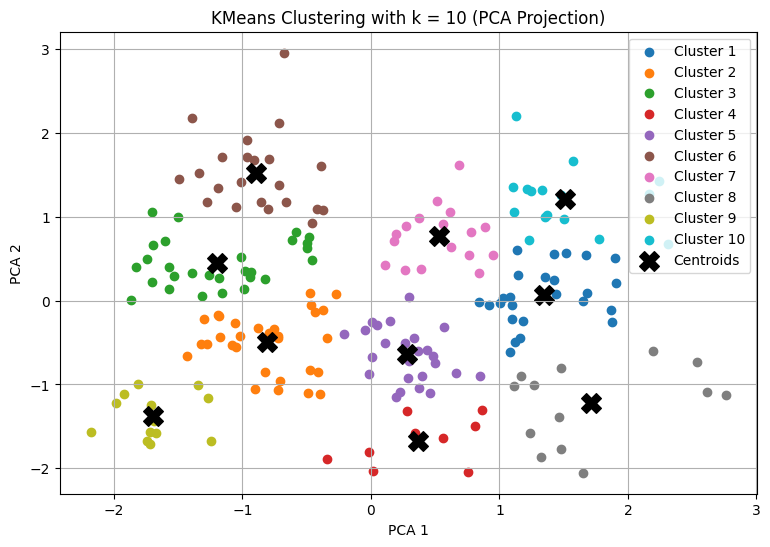

In [30]:
# KMeans clustering with k=10 and PCA projection for visualization
kmeans_final = KMeans(n_clusters=10, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(ftrs_pca)
plt.figure(figsize=(9,6))
for i in range(10):
    plt.scatter(ftrs_pca[clusters == i, 0], ftrs_pca[clusters == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('KMeans Clustering with k = 10 (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

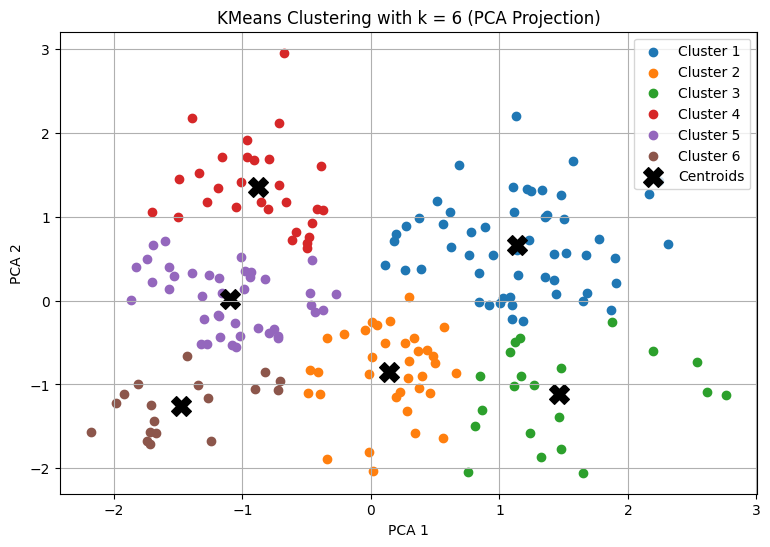

In [31]:
# KMeans clustering with k=6 and PCA projection for visualization
kmeans_final = KMeans(n_clusters=6, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(ftrs_pca)
plt.figure(figsize=(9,6))
for i in range(6):
    plt.scatter(ftrs_pca[clusters == i, 0], ftrs_pca[clusters == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('KMeans Clustering with k = 6 (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

upon reviewing cluster diagrams k6 seems optimal

In [32]:
# Use the original features (scaled) and cluster labels (k=6) as targets

kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(ftrs_scaled)

X_train, X_test, y_train, y_test = train_test_split(ftrs_scaled, cluster_labels, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

# Add cross-validation to check for overfitting 
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, ftrs_scaled, cluster_labels, cv=5)

print('Cross-validation scores:', cv_scores)
print('Mean CV score:', np.mean(cv_scores))
print('Std CV score:', np.std(cv_scores))

# Example: Assign a new data point to a cluster
example = pd.DataFrame([[1, 35, 60, 50]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)
assigned_cluster = kmeans.predict(example_scaled)
print('Example data:', example.values[0])
print('Assigned to cluster:', assigned_cluster[0])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         8

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[ 6  0  0  0  0  0]
 [ 0 10  0  0  0  0]
 [ 0  0 10  0  0  0]
 [ 0  0  0  2  0  0]
 [ 0  0  0  0  4  0]
 [ 0  0  0  0  0  8]]
Cross-validation scores: [0.775      0.975      1.         0.97435897 0.79487179]
Mean CV score: 0.9038461538461539
Std CV score: 0.0

In [33]:
# Example: Assign a new data point to a cluster
example = pd.DataFrame([[1, 35, 23, 90]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)
assigned_cluster = kmeans.predict(example_scaled)
print('Example data:', example.values[0])
print('Assigned to cluster:', assigned_cluster[0])

Example data: [ 1 35 23 90]
Assigned to cluster: 2


In [34]:
# Add cluster assignments to both df and ftrs DataFrames
ftrs_scaled_all = scalar.transform(ftrs)
assigned_clusters = kmeans.predict(ftrs_scaled_all)
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = assigned_clusters
ftrs_with_clusters = ftrs.copy()
ftrs_with_clusters['Cluster'] = assigned_clusters
print('df with clusters:')
print(df_with_clusters.head())
print('ftrs with clusters:')
print(ftrs_with_clusters.head())


df with clusters:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  
ftrs with clusters:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   19                  15                      39        2
1       1   21                  15                      81        2
2       0   20                  16                       6        2
3       0   23                  16                      77        2
4       0   31                  17                      40        2


In [35]:
df = df_with_clusters


In [36]:
df = ftrs_with_clusters

In [37]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,2
3,0,23,16,77,2
4,0,31,17,40,2


In [38]:
df.tail()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
193,0,38,113,91,1
194,0,47,120,16,3
195,0,35,120,79,1
196,0,45,126,28,3
197,1,32,126,74,1


In [39]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(cluster_summary)

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        56.0                47.3                    39.6
1        32.8                85.2                    82.1
2        24.7                40.0                    61.7
3        41.2                87.9                    24.6
4        38.8                83.1                    14.0
5        49.8                47.4                    41.1


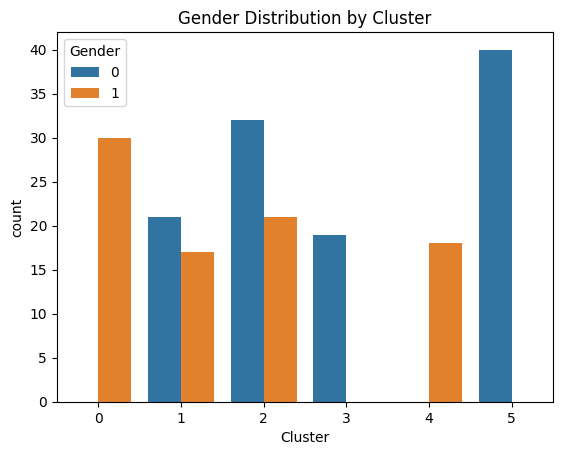

In [41]:
sns.countplot(x='Cluster', hue='Gender', data=df)
plt.title('Gender Distribution by Cluster')
plt.show()

In [42]:
example = pd.DataFrame([[0, 17, 473, 90]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)
assigned_cluster = kmeans.predict(example_scaled)
print('Example data:', example.values[0])
print('Assigned to cluster:', assigned_cluster[0])

Example data: [  0  17 473  90]
Assigned to cluster: 1


In [43]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,2
3,0,23,16,77,2
4,0,31,17,40,2


In [44]:
# Define cluster labels based on analysis
cluster_labels = {
    0: 'Older Mid-Income Conservative Males',
    1: 'Young High-Income Power Shoppers',
    2: 'Young Budget Spenders (Female-Oriented)',
    3: 'Wealthy Conservative Men',
    4: 'Disengaged High-Earning Males',
    5: 'Middle-Aged Moderate-Spending Females'
}

In [45]:
df['Cluster Label'] = df['Cluster'].map(cluster_labels)



In [47]:
example = pd.DataFrame([[1, 22, 100, 21]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)
assigned_cluster = kmeans.predict(example_scaled)
print('Example data:', example.values[0])
print('Assigned to cluster:', assigned_cluster[0])

Example data: [  1  22 100  21]
Assigned to cluster: 4


In [48]:
df['Income_per_Age'] = df['Annual Income (k$)'] / df['Age']

In [49]:
df['Spending_to_Income'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']

In [54]:
cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'median'],
    'Annual Income (k$)': ['mean', 'median'],
    'Spending Score (1-100)': ['mean', 'median'],
    'Income_per_Age': ['mean', 'median'],
    'Spending_to_Income': ['mean', 'median'],
    'Gender': 'mean'  #encoded as 0/1, mean gives % male/female
}).round(2)

cluster_profile.columns = ['_'.join([str(c) for c in col]).strip() for col in cluster_profile.columns.values]
cluster_profile['Spending_to_Income'] = (
    cluster_profile['Spending Score (1-100)_mean'] / cluster_profile['Annual Income (k$)_mean']
).round(2)

print(cluster_profile)




         Age_mean  Age_median  Annual Income (k$)_mean  \
Cluster                                                  
0           56.00        58.0                    47.27   
1           32.76        32.0                    85.21   
2           24.72        23.0                    40.02   
3           41.21        41.0                    87.89   
4           38.83        41.0                    83.06   
5           49.78        49.0                    47.40   

         Annual Income (k$)_median  Spending Score (1-100)_mean  \
Cluster                                                           
0                             51.5                        39.57   
1                             78.5                        82.11   
2                             40.0                        61.70   
3                             79.0                        24.58   
4                             79.5                        14.00   
5                             48.5                        41.08   


| Cluster | Avg Age | Income (k$) | Income/Age | Spending/Income | Gender (F / M) | Segment Insight |
|--------:|:-------:|:-----------:|:----------:|:----------------:|:---------------|-----------------|
| 0       | 56.0    | 47.3        | **0.84**   | **0.84**         | 0% / 100%      | Older men with steady income and controlled spending. Likely conservative, loyal, and financially cautious. Not impulsive. |
| 1       | 32.8    | 85.2        | **2.60**   | **0.96**         | 55% / 45%      | Young professionals with high income and decent spending. A perfect target for premium products and personalized marketing. |
| 2       | 24.7    | 40.0        | **1.62**   | **1.54**         | 60% / 40%      | Very young, mostly women with moderate income but high spending. Trend-following and brand-conscious; ideal for aspirational branding. |
| 3       | 41.2    | 87.9        | **2.13**   | **0.28**         | 0% / 100%      | High-income middle-aged men, but very low spenders. Likely value-focused or prefer saving. Not easily influenced by marketing. |
| 4       | 38.8    | 83.1        | **2.14**   | **0.17**         | 0% / 100%      | Wealthy men who barely spend. Extremely cautious or uninterested in typical consumption; may respond to exclusivity or investment-type offers. |
| 5       | 49.8    | 47.4        | **0.95**   | **0.87**         | 100% / 0%      | Older women with lower income but relatively good spending. Possibly loyal shoppers who value good deals and consistent quality. |



In [56]:
example = pd.DataFrame([[1, 48, 555, 10]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)
assigned_cluster = kmeans.predict(example_scaled)
print('Example data:', example.values[0])
print('Assigned to cluster:', assigned_cluster[0])

Example data: [  1  48 555  10]
Assigned to cluster: 3


In [57]:
df.head(20)

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster Label,Income_per_Age,Spending_to_Income
0,1,19,15,39,2,Young Budget Spenders (Female-Oriented),0.789474,2.600000
1,1,21,15,81,2,Young Budget Spenders (Female-Oriented),0.714286,5.400000
2,0,20,16,6,2,Young Budget Spenders (Female-Oriented),0.800000,0.375000
3,0,23,16,77,2,Young Budget Spenders (Female-Oriented),0.695652,4.812500
4,0,31,17,40,2,Young Budget Spenders (Female-Oriented),0.548387,2.352941
5,0,22,17,76,2,Young Budget Spenders (Female-Oriented),0.772727,4.470588
6,0,35,18,6,5,Middle-Aged Moderate-Spending Females,0.514286,0.333333
7,0,23,18,94,2,Young Budget Spenders (Female-Oriented),0.782609,5.222222
8,1,64,19,3,0,Older Mid-Income Conservative Males,0.296875,0.157895
9,0,30,19,72,2,Young Budget Spenders (Female-Oriented),0.633333,3.789474
